# Gradient Boosting 

This file will explore the gradient boosting model and apply hyperparameter tuning. 

## Import packages 

In [1]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

In [9]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from src.modeling.evaluation import evaluate_classifier

# Load Dataset 

In [5]:
features = pd.read_csv("../data/final/nutriaccess_features_sample.csv")
print(features.columns.tolist())

['state', 'county', 'urban_share', 'population_2010', 'avg_poverty_rate', 'avg_median_family_income', 'low_income_tracts_count', 'lila_1_10_count', 'lila_half_10_count', 'lila_1_20_count', 'total_housing_units_no_vehicle', 'total_snap_households', 'tract_count', 'total_population', 'male_population', 'female_population', 'median_age', 'poverty_rate', 'median_income', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity', 'pct_diabetes_adults19', 'pct_obese_adults22', 'povrate21', 'high_food_access_risk']


## Data Prep 

In [6]:
# import prepared data 
from src.modeling.data_prep import prepare_model_data

data = prepare_model_data(features)

## Modeling 

In [7]:
# Gradeient boost 
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(data["X_train"], data["y_train"])

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


accuracy: 0.889
balanced_accuracy: 0.862
precision_class_1: 0.800
recall_class_1: 0.800
f1_class_1: 0.800
roc_auc: 0.985
pr_auc: 0.967

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        13
           1       0.80      0.80      0.80         5

    accuracy                           0.89        18
   macro avg       0.86      0.86      0.86        18
weighted avg       0.89      0.89      0.89        18



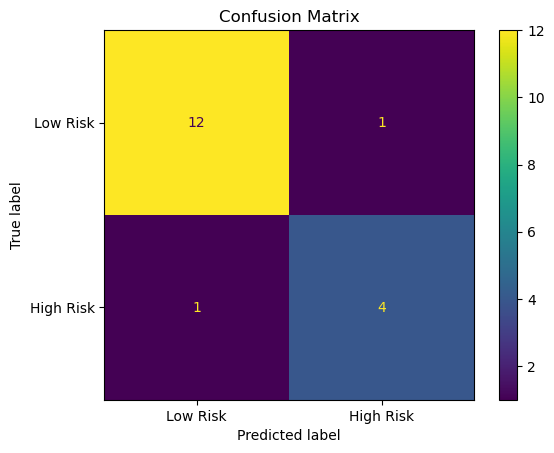

In [8]:
metrics_gb, coef_df_gb = evaluate_classifier(
    gb_model,
    data["X_test"],
    data["y_test"],
    feature_names=data["X"].columns
)

The baseline Gradient Boosting model demonstrated strong performance, achieving a balanced accuracy of 0.862 and an F1-score of 0.80 for the minority class. The model also achieved high ROC-AUC (0.985) and PR-AUC (0.967), indicating strong class separability. However, due to the relatively small test sample size, these results should be interpreted cautiously and validated further through cross-validation and hyperparameter tuning.

Identifying high-risk counties is the priority; recall may be a metric that is aligned with the business goal.

## Hyperparameter Tuning 

In [12]:
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

gb = GradientBoostingClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

grid.fit(data["X_train"], data["y_train"])

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best CV score: 0.9


Hyperparameter tuning for Gradient Boosting was performed using GridSearchCV with stratified 3-fold cross-validation and F1-score as the optimization metric. The best configuration used a learning rate of 0.1, shallow trees (max_depth=2), a minimum leaf size of 3, and 50 estimators. This configuration achieved a cross-validated F1-score of 1.0, though the results were interpreted cautiously due to the small dataset.

Tuning was repeated with CV=5. F1-score was strong at 0.9. The model performs very well, but test performance is likely inflated due to the small sample size. Increasing cross-validation from 3-folds to 5-folds produced a more realistic model performance. 

accuracy: 1.000
balanced_accuracy: 1.000
precision_class_1: 1.000
recall_class_1: 1.000
f1_class_1: 1.000
roc_auc: 1.000
pr_auc: 1.000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         5

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



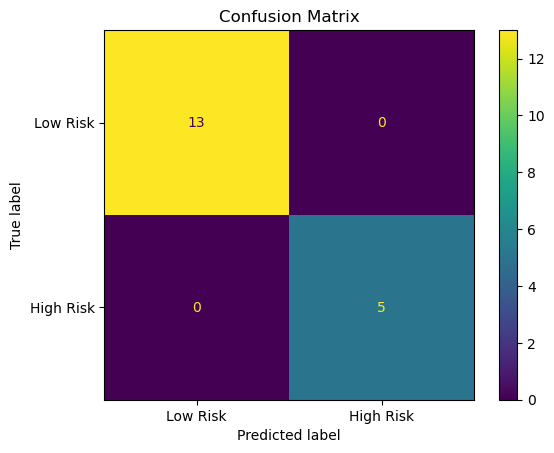

In [14]:
best_gb = grid.best_estimator_

metrics_gb, importance_gb = evaluate_classifier(
    best_gb,
    data["X_test"],
    data["y_test"],
    feature_names=data["X"].columns
)

Model achives perfect perfomance on small test set so results may not generalize. 